In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import lightgbm as lgb

In [2]:
df = pd.read_csv(r"..\dataset\data.csv")

C:\Users\Yug Patel\AppData\Local\Temp\ipykernel_1720\3496608382.py:1: DtypeWarning: Columns (15,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\dataset\data.csv")


In [3]:
df.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,state,type_x,cluster,dcoilwtico,transactions,type_y,locale,locale_name,description,transferred
0,22,2013-01-01,25,119187,1.0,False,CLEANING,3044,0,Salinas,Santa Elena,D,1,93.14,770.0,Holiday,National,Ecuador,Primer dia del ano,False
1,54,2013-01-01,25,205387,1.0,False,GROCERY I,1034,0,Salinas,Santa Elena,D,1,93.14,770.0,Holiday,National,Ecuador,Primer dia del ano,False
2,89,2013-01-01,25,265257,5.0,False,GROCERY I,1016,0,Salinas,Santa Elena,D,1,93.14,770.0,Holiday,National,Ecuador,Primer dia del ano,False
3,131,2013-01-01,25,319094,1.0,False,DELI,2632,1,Salinas,Santa Elena,D,1,93.14,770.0,Holiday,National,Ecuador,Primer dia del ano,False
4,142,2013-01-01,25,358096,1.0,False,GROCERY I,1002,0,Salinas,Santa Elena,D,1,93.14,770.0,Holiday,National,Ecuador,Primer dia del ano,False


In [4]:
df = df.rename(columns={"type_x": "store_type", "type_y": "holiday_type"})

In [5]:
df['dcoilwtico'] = df['dcoilwtico'].fillna(df['dcoilwtico'].median())
df['transactions'] = df['transactions'].fillna(0)
df['holiday_type'] = df['holiday_type'].fillna('No Holiday')
df['locale'] = df['locale'].fillna('No Holiday')
df['locale_name'] = df['locale_name'].fillna('No Holiday')
df['description'] = df['description'].fillna('No Holiday')
df['transferred'] = df['transferred'].fillna(False)

C:\Users\Yug Patel\AppData\Local\Temp\ipykernel_1720\3850623225.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['transferred'] = df['transferred'].fillna(False)


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'store_nbr'}>,
        <Axes: title={'center': 'item_nbr'}>],
       [<Axes: title={'center': 'unit_sales'}>,
        <Axes: title={'center': 'class'}>,
        <Axes: title={'center': 'perishable'}>],
       [<Axes: title={'center': 'cluster'}>,
        <Axes: title={'center': 'dcoilwtico'}>,
        <Axes: title={'center': 'transactions'}>]], dtype=object)

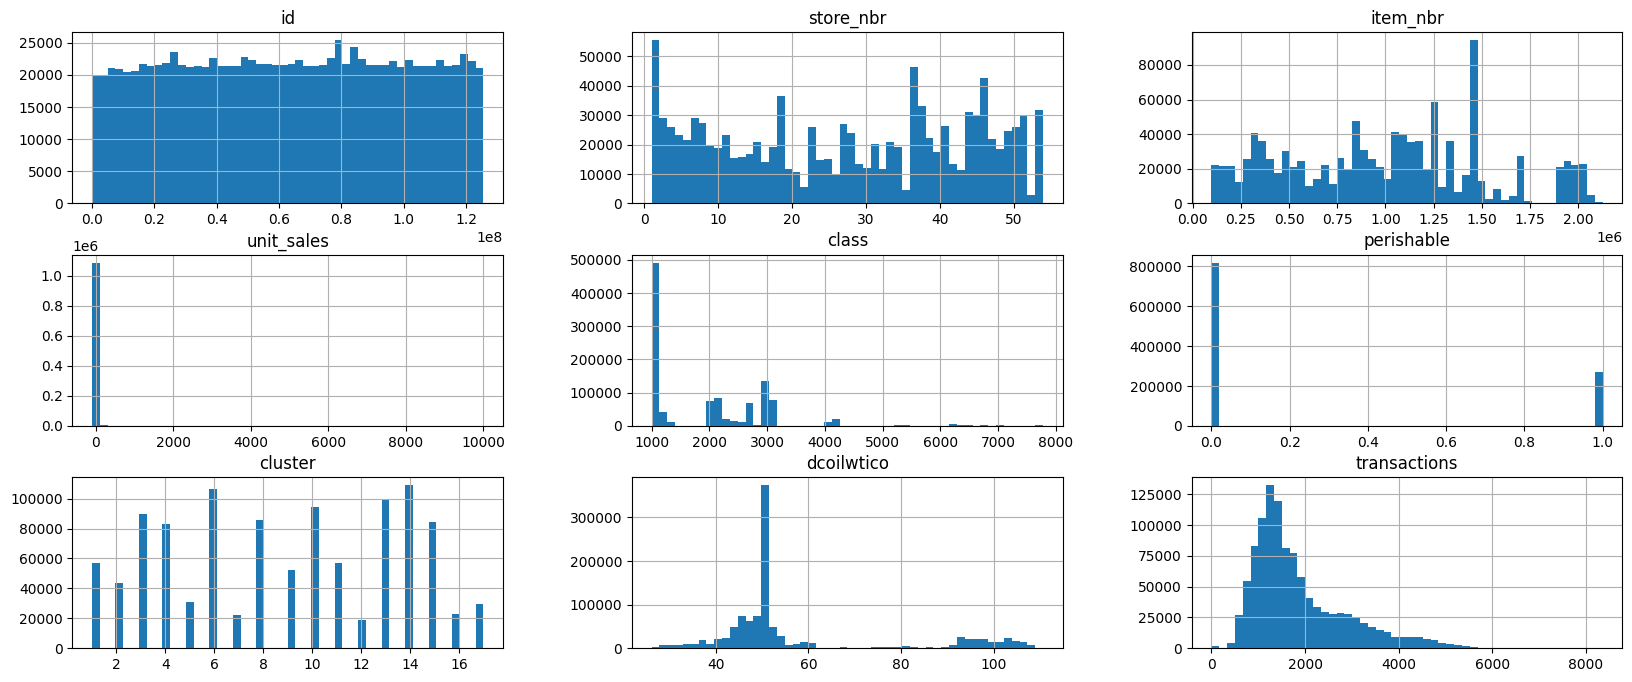

In [6]:
df.hist(bins=50, figsize=(20,8))

In [7]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["dayofyear"] = df["date"].dt.dayofyear
df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

In [8]:
df["transactions"] = np.log1p(df["transactions"])

In [9]:
df = df.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

In [10]:
lag_days = [1,7,14,28]
for lag in lag_days:
    df[f"lag_{lag}"]=(
        df.groupby(["store_nbr","item_nbr"])["unit_sales"].shift(lag)
        )

In [11]:
windows = [7, 14, 30]

for window in windows:

    df[f"rolling_mean_{window}"] = (
        df.groupby(["store_nbr", "item_nbr"])["unit_sales"]
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

    df[f"rolling_std_{window}"] = (
        df.groupby(["store_nbr", "item_nbr"])["unit_sales"]
        .transform(lambda x: x.shift(1).rolling(window).std())
    )

    df[f"rolling_max_{window}"] = (
        df.groupby(["store_nbr", "item_nbr"])["unit_sales"]
        .transform(lambda x: x.shift(1).rolling(window).max())
    )

    df[f"rolling_min_{window}"] = (
        df.groupby(["store_nbr", "item_nbr"])["unit_sales"]
        .transform(lambda x: x.shift(1).rolling(window).min())
    )

    df[f"rolling_median_{window}"] = (
        df.groupby(["store_nbr", "item_nbr"])["unit_sales"]
        .transform(lambda x: x.shift(1).rolling(window).median())
    )

In [12]:
df["oil_two_days_diff"] = df["dcoilwtico"].diff(2)

In [13]:
windows = [7, 14, 30]

for window in windows:

    df[f"oil_mean_{window}"] = (
        df["dcoilwtico"]
        .shift(1)
        .rolling(window)
        .mean()
    )

    df[f"oil_std_{window}"] = (
        df["dcoilwtico"]
        .shift(1)
        .rolling(window)
        .std()
    )

    df[f"oil_max_{window}"] = (
        df["dcoilwtico"]
        .shift(1)
        .rolling(window)
        .max()
    )

    df[f"oil_min_{window}"] = (
        df["dcoilwtico"]
        .shift(1)
        .rolling(window)
        .min()
    )

    df[f"oil_median_{window}"] = (
        df["dcoilwtico"]
        .shift(1)
        .rolling(window)
        .median()
    )

In [15]:
df.columns

Index(['id', 'date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion',
       'family', 'class', 'perishable', 'city', 'state', 'store_type',
       'cluster', 'dcoilwtico', 'transactions', 'holiday_type', 'locale',
       'locale_name', 'description', 'transferred', 'year', 'month', 'week',
       'day', 'dayofweek', 'dayofyear', 'quarter', 'is_weekend',
       'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_28',
       'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7',
       'rolling_median_7', 'rolling_mean_14', 'rolling_std_14',
       'rolling_max_14', 'rolling_min_14', 'rolling_median_14',
       'rolling_mean_30', 'rolling_std_30', 'rolling_max_30', 'rolling_min_30',
       'rolling_median_30', 'oil_two_days_diff', 'oil_mean_7', 'oil_std_7',
       'oil_max_7', 'oil_min_7', 'oil_median_7', 'oil_mean_14', 'oil_std_14',
       'oil_max_14', 'oil_min_14', 'oil_median_14', 'oil_mean_30',
       'oil_std_30', 'oil_max_30', 'oil_min_30', 'oil_

In [14]:

# df.to_parquet("featured_data.parquet", index=False, engine="fastparquet")